# Bulk RNA-seq: Hippocampal iPSC Time Course 

This notebook fits **one** pyDESeq2 model and derives every figure and table from it,
so the main text, figures and supplementary tables all use the same statistics.

**Analysis in one paragraph (for methods):** raw counts were filtered to genes with
≥ 10 total reads; PyDESeq2 was fit with a categorical design `~div` (DIV 0 as reference).
Each DIV bin was compared to DIV 0 with a thresholded Wald test (H₀: |log₂FC| ≤ 1,
`alt_hypothesis="greaterAbs"`), BH-adjusted with independent filtering (α = 0.05).
Reported fold changes are apeGLM-shrunk; p-values come from the unshrunk fit.
Heatmaps and PCA use the blind VST. GO enrichment (Enrichr via gseapy) uses the
genes that received an adjusted p-value as background.

In [5]:
# Set up libraries and configuration
import os, re, textwrap, warnings
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference
from itertools import combinations
import gseapy as gp

# Import gene count matrix 
COUNTS_PATH    = "gene_count_matrix.txt"   # genes x samples, tab-separated
FIG_DIR        = "Bulk Figures"
SUPP_DIR       = "Supplementary"

N_CPUS         = 4
MIN_GENE_TOTAL = 10       # Drop genes with fewer total reads (after sample filtering)
PADJ_CUT       = 0.05     # FDR-adjusted p-value cutoff
LFC_NULL       = 1.0      # Thresholded Wald test: H0 |log2FC| <= LFC_NULL
TOP_N          = 500      # Genes per direction in the genome-wide heatmap / top tables
RANK_BY        = "lfc"    # "lfc" (shrunk log2FC) or "stat" (Wald statistic)
VOLCANO_MARKERS = []      # Genes to label in black on every volcano, e.g. ["PROX1", "CALB1"]

RUN_GO         = True    
GO_ORGANISM    = "human"

# Sample-name adjustments: DIV in sample labels
# Sample with "DIV111" corresponds to DIV11 and sample with "DIV1001" corresponds to DIV100
DIV_RELABEL = {111: 11, 1001: 100}

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SUPP_DIR, exist_ok=True)
INFERENCE = DefaultInference(n_cpus=N_CPUS)

# Culture stage Labels
BIN_ORDER = ["DIV0", "DIV11", "DIV40", "DIV60", "DIV82to100", "DIV154to200"]
DISPLAY = {"DIV0": "DIV 0", "DIV11": "DIV 11", "DIV40": "DIV 40", "DIV60": "DIV 60",
           "DIV82to100": "DIV 82-100", "DIV154to200": "DIV 154-200"}
BIN_COLORS = dict(zip(BIN_ORDER, ["#1F77B4", "#9EDAE5", "#2CA02C",
                                  "#BDD438", "#EB50E3", "#9467BD"]))
REF, LAST = BIN_ORDER[0], BIN_ORDER[-1]
print("pydeseq2", pydeseq2.__version__)

pydeseq2 0.5.4


## 1. Load counts and build sample metadata

In [7]:
# Read gene count matrix
# There should be 17 samples x 39533 genes for the raw matrix
raw = pd.read_csv(COUNTS_PATH, sep="\t", index_col=0)

counts_all = raw.T                      # Samples x Genes
counts_all.index = counts_all.index.astype(str)
print(f"input: {counts_all.shape[0]} samples x {counts_all.shape[1]} genes")

input: 17 samples x 39533 genes


In [18]:
def div_to_group(div):
    # Map an actual day to its culture stage bin
    if div is None or pd.isna(div):
        return None
    if div == 0:            return "DIV0"
    if div == 11:           return "DIV11"
    if div == 40:           return "DIV40"
    if 50 <= div <= 70:     return "DIV60"
    if 71 <= div <= 120:    return "DIV82to100"
    if div >= 121:          return "DIV154to200"
    return None

def parse(sample):
    d = re.search(r"DIV(\d+)", sample)
    raw_div = int(d.group(1)) if d else None
    div = DIV_RELABEL.get(raw_div, raw_div)
    culture = (None if div is None else
               "iPSC" if div == 0 else "NEP" if div == 11 else "Organoid")
    return {"culture": culture,
            "div": div_to_group(div),
            "div_actual": div,
            "div_label_in_name": raw_div,
            "relabeled": raw_div != div}

meta_all = pd.DataFrame.from_records([parse(s) for s in counts_all.index],
                                     index=counts_all.index)

ok = meta_all["div"].notna()
if (~ok).any():
    print("dropping samples with no DIV bin:", list(meta_all.index[~ok]))
counts, meta = counts_all.loc[ok].copy(), meta_all.loc[ok].copy()
meta["div_actual"] = meta["div_actual"].astype(int)
meta["div"] = pd.Categorical(meta["div"], categories=BIN_ORDER, ordered=False).astype(str)

# Order samples chronologically
order_idx = meta.sort_values("div_actual", kind="stable").index
counts, meta = counts.loc[order_idx], meta.loc[order_idx]

missing_bins = [b for b in BIN_ORDER if b not in set(meta["div"])]
if missing_bins:
    raise ValueError(f"no samples in bins {missing_bins}")

print(meta[["culture", "div", "div_actual"]].to_string())
print("\nsamples per bin:")
print(meta["div"].value_counts().reindex(BIN_ORDER, fill_value=0))

                        culture          div  div_actual
CLV5-1IPSCDIV0             iPSC         DIV0           0
CLV5-1IPSCp70DIV0          iPSC         DIV0           0
CLV5-1p46DIV0              iPSC         DIV0           0
CLV5-1HIPPODIV111           NEP        DIV11          11
CLV5-1HIPPODIV11            NEP        DIV11          11
CLV3-1HIPPODIV40       Organoid        DIV40          40
CLV4-4HIPPOORGDIV40    Organoid        DIV40          40
CLV5-1HIPPODIV40       Organoid        DIV40          40
CLV5-1HIPPOORGDIV60    Organoid        DIV60          60
CLV4-4HIPPOORGDIV60    Organoid        DIV60          60
CLV5-1HIPPOORGDIV82    Organoid   DIV82to100          82
CLV5-1HIPPOORGDIV84    Organoid   DIV82to100          84
CLV5-1HIPPOORGDIV1001  Organoid   DIV82to100         100
CLV5-1HIPPOORGDIV100   Organoid   DIV82to100         100
CLV5-1HIPPOORGDIV154   Organoid  DIV154to200         154
CLV5-1HIPPOORGDIV180   Organoid  DIV154to200         180
CLV5-1HIPPOORGDIV200   Organoid

## 2. Fit model

In [20]:
# Apply gene filter (Genes with a total count below 10 across all samples are removed)
counts = counts.loc[:, counts.sum(axis=0) >= MIN_GENE_TOTAL].round().astype(int)
print(f"after filter: {counts.shape[0]} samples x {counts.shape[1]} genes")

if sorted(meta["div"].unique())[0] != REF:
    raise ValueError("DIV0 would not be the reference level - rename the levels")

dds = DeseqDataSet(counts=counts, metadata=meta, design="~div",
                   refit_cooks=True, inference=INFERENCE, quiet=True)
dds.deseq2()
dds.vst(use_design=False)                   

COEFS = list(dds.varm["LFC"].columns)
expected = [f"div[T.{b}]" for b in BIN_ORDER[1:]]
if not all(c in COEFS for c in expected):
    raise ValueError(f"unexpected coefficients {COEFS}; expected {expected}")
print("coefficients:", COEFS)

VST = pd.DataFrame(np.asarray(dds.layers["vst_counts"]),
                   index=np.asarray(dds.obs_names), columns=np.asarray(dds.var_names))
SAMPLE_BIN = dds.obs["div"].astype(str).to_numpy()

# Final preprocessed gene count matrix should have 17 samples x 26293 genes
GENES = pd.Index(VST.columns)

after filter: 17 samples x 26293 genes
coefficients: ['Intercept', 'div[T.DIV11]', 'div[T.DIV154to200]', 'div[T.DIV40]', 'div[T.DIV60]', 'div[T.DIV82to100]']


In [30]:
def run_contrast(dds_, test, ref, shrink=True):
    # LFC shrinkage is applied for gene ranking, however the p-values are not affected by it
    ds = DeseqStats(dds_, contrast=["div", test, ref], alpha=PADJ_CUT,
                    lfc_null=LFC_NULL, alt_hypothesis="greaterAbs",
                    inference=INFERENCE, quiet=True)
    ds.summary()
    mle = ds.results_df.copy()

    coeff = f"div[T.{test}]"
    coefs = list(dds_.varm["LFC"].columns)
    model_ref = ref == sorted(dds_.obs["div"].astype(str).unique())[0]
    if shrink and model_ref and coeff in coefs:
        ds.lfc_shrink(coeff=coeff)
        shr = ds.results_df.copy()
        if not np.allclose(shr["padj"].fillna(-1), mle["padj"].fillna(-1)):
            raise RuntimeError("padj changed after shrinkage")
        big = mle["log2FoldChange"].abs() > 1
        agree = (np.sign(shr.loc[big, "log2FoldChange"])
                 == np.sign(mle.loc[big, "log2FoldChange"])).mean()
        if agree < 0.95:
            raise RuntimeError(f"{test} vs {ref}: shrinkage flipped signs ({agree:.1%} agree)")
        lfc, se, lfc_type = shr["log2FoldChange"], shr["lfcSE"], "apeGLM-shrunk"
    else:
        lfc, se, lfc_type = mle["log2FoldChange"], mle["lfcSE"], "MLE (unshrunk)"

    res = pd.DataFrame({
        "baseMean": mle["baseMean"],
        "log2FoldChange": lfc,
        "lfcSE": se,
        "log2FoldChange_MLE": mle["log2FoldChange"],
        "lfcSE_MLE": mle["lfcSE"],
        "stat": mle["stat"],
        "pvalue": mle["pvalue"],
        "padj": mle["padj"],
    }).reindex(np.asarray(dds_.var_names))
    res.index.name = "gene"

    res["test_status"] = np.select(
        [res["pvalue"].isna(), res["padj"].isna()],
        ["no p-value (Cook's outlier)", "not adjusted (independent filtering)"],
        default="tested")
    sig = res["padj"].lt(PADJ_CUT).fillna(False)
    res["direction"] = np.where(sig & (res["log2FoldChange"] > 0), "up",
                       np.where(sig & (res["log2FoldChange"] < 0), "down", "ns"))
    res["comparison"] = f"{DISPLAY[test]} vs {DISPLAY[ref]}"
    res["lfc_type"] = lfc_type
    return res


def summarize(res):
    s = res["test_status"].value_counts()
    return {"comparison": res["comparison"].iat[0],
            "lfc_type": res["lfc_type"].iat[0],
            "genes_in_model": len(res),
            "tested (padj available)": int(s.get("tested", 0)),
            "independent filtering (padj NaN)": int(s.get("not adjusted (independent filtering)", 0)),
            "Cook's outlier (pvalue NaN)": int(s.get("no p-value (Cook's outlier)", 0)),
            "up": int((res["direction"] == "up").sum()),
            "down": int((res["direction"] == "down").sum())}

In [38]:
# Every culture stage bin vs DIV 0
with np.errstate(over="ignore"):
    RESULTS = {b: run_contrast(dds, b, REF) for b in BIN_ORDER[1:]}
RES = RESULTS[LAST]                                   # main comparison

SUMMARY = pd.DataFrame([summarize(r) for r in RESULTS.values()])
print(SUMMARY.to_string(index=False))

/usr/local/lib/python3.13/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


          comparison      lfc_type  genes_in_model  tested (padj available)  independent filtering (padj NaN)  Cook's outlier (pvalue NaN)   up  down
     DIV 11 vs DIV 0 apeGLM-shrunk           26293                    20564                              5606                          123 1108  1582
     DIV 40 vs DIV 0 apeGLM-shrunk           26293                    21583                              4587                          123 2857  2504
     DIV 60 vs DIV 0 apeGLM-shrunk           26293                    21074                              5096                          123 3578  2836
 DIV 82-100 vs DIV 0 apeGLM-shrunk           26293                    23111                              3059                          123 4036  3219
DIV 154-200 vs DIV 0 apeGLM-shrunk           26293                    22092                              4078                          123 4026  3140


In [ ]:
# To run all pairwise comparisons between culture stage bins
# BIN_ORDER runs earliest -> latest, so 'hi' is always the later bin
# Positive log2FC = higher in the later timepoin
PAIRWISE = {}
for i, j in combinations(range(len(BIN_ORDER)), 2):
    lo, hi = BIN_ORDER[i], BIN_ORDER[j]
    if lo == REF:
        PAIRWISE[(hi, lo)] = RESULTS[hi]             
    else:
        print(f"testing {lab(hi)} vs {lab(lo)}")
        PAIRWISE[(hi, lo)] = run_contrast(dds, hi, lo)

PAIRWISE_SUMMARY = pd.DataFrame([summarize(r) for r in PAIRWISE.values()])
PAIRWISE_SUMMARY.insert(0, "comparison", [f"{lab(hi)} vs {lab(lo)}" for hi, lo in PAIRWISE])
PAIRWISE_SUMMARY.insert(1, "tested_level", [lab(hi) for hi, lo in PAIRWISE])
PAIRWISE_SUMMARY.insert(2, "reference_level", [lab(lo) for hi, lo in PAIRWISE])
print(PAIRWISE_SUMMARY.to_string(index=False))

# One combined sheet: every gene x every comparison (log2FC + padj) 
PAIRWISE_WIDE = pd.concat(
    [r[["log2FoldChange", "padj"]].rename(columns={
        "log2FoldChange": f"log2FC_{hi}_vs_{lo}",
        "padj":           f"padj_{hi}_vs_{lo}"})
     for (hi, lo), r in PAIRWISE.items()],
    axis=1)
PAIRWISE_WIDE.index.name = "gene"

# Save results
PAIRWISE_TABLE_ID = "S25-39"          

pw_sheets = [
    ("Pairwise_summary", PAIRWISE_SUMMARY, False,
     f"Number of differentially expressed genes for all {len(PAIRWISE)} pairwise DIV "
     f"comparisons (padj < {PADJ_CUT})"),
    ("All_comparisons_combined", PAIRWISE_WIDE, True,
     "log2 fold change and BH-adjusted p-value for every gene in every pairwise comparison; "
     "positive log2FC = higher in the later timepoint"),
]
pw_sheets += [
    (f"{hi}_vs_{lo}", r, True,
     f"All tested genes, {lab(hi)} vs {lab(lo)}: DESeq2 Wald test, BH-adjusted; "
     f"positive log2FC = higher at {lab(hi)}")
    for (hi, lo), r in PAIRWISE.items()
]
write_book(f"{SUPP_DIR}/Supplementary_Table_DE_pairwise.xlsx", pw_sheets,
           table_id=PAIRWISE_TABLE_ID, title="All pairwise differential expression comparisons")

In [39]:
# Top genes of the main comparison (DIV 0 vs DIV 154-200)
score = RES["log2FoldChange"] if RANK_BY == "lfc" else RES["stat"]
TOP_UP   = RES[RES["direction"] == "up"].assign(_s=score).sort_values("_s", ascending=False).head(TOP_N).drop(columns="_s")
TOP_DOWN = RES[RES["direction"] == "down"].assign(_s=score).sort_values("_s", ascending=True).head(TOP_N).drop(columns="_s")
print(f"{DISPLAY[LAST]} vs {DISPLAY[REF]}: {(RES.direction=='up').sum()} up, "
      f"{(RES.direction=='down').sum()} down; showing top {len(TOP_UP)} / {len(TOP_DOWN)}")
cols = ["log2FoldChange", "log2FoldChange_MLE", "stat", "padj"]
print("\nTop up:\n", TOP_UP[cols].head(10))
print("\nTop down:\n", TOP_DOWN[cols].head(10))

DIV 154-200 vs DIV 0: 4026 up, 3140 down; showing top 500 / 500

Top up:
            log2FoldChange  log2FoldChange_MLE      stat          padj
gene                                                                 
PMP2            17.631703           17.039039  6.893876  6.253513e-11
NEUROD6         15.305706           14.788393  6.139539  7.703174e-09
LINC00473       15.104901           14.362924  6.511468  7.711465e-10
OMG             14.700127           13.771887  6.297348  2.953216e-09
ABCA8           14.696365           14.117324  5.770076  6.670484e-08
DCN             14.341801           13.914797  5.300351  8.452164e-07
B3GALT2         14.219872           13.607807  6.368001  1.910923e-09
SCRG1           14.176587           13.533779  6.310033  2.730680e-09
LUM             14.143273           13.610615  5.631330  1.449235e-07
MGP             13.712560           13.619522  4.227242  1.264546e-04

Top down:
               log2FoldChange  log2FoldChange_MLE       stat          padj


## 3. Gene Lists (For plotting)

In [46]:
GENE_LISTS = {
    # Astrocyte gene markers
    "astrocyte": ["GFAP", "S100B", "ALDH1L1", "SLC1A2", "SOX9", "AQP4", "NDRG2", "VIM"],
    # Excitatory & Neuronal Genes
    "excitatory_neuronal": ['CAMK2A', 'GRIA2', 'TBR1', 'DCX', 'GRIA1', 'SNAP25','TUBA1A', 'NEUROG2', 
    'TUBB3', 'SOX4', 'NEUROG1', 'POU3F1', 'GRIN1', 'C1QL2', 'GRIK4', 'SATB2', 'SLC17A7', 
    'PCP4', 'NEUROD2', 'NEUROD6', 'SCGN', 'RBFOX3', 'SCN1A', 'SCN3A', 'PRPH', 'CHAT',
    'POU3F2', 'SCN5A','TCF7L2', 'SLC6A2'],
    # 23 signature genes (Sarkar et al.)
    "ca3_sarkar": ["HSPA2", "MYO5B", "SGK1", "KIT", "LPL", "GRIK4", "SH3GL2", "SEZ6", "SOCS2",
        "ELAVL4", "SNAP91", "PKIA", "ELAVL2", "NEFL", "CHGB", "CADPS", "SNCA", "SCGN",
        "TGFB2", "SPOCK1", "CACNA1A", "NEUROD6"],
    # Figure 7b markers
    "fig7b": ["TRIB2", "BCL11B", "FIBCD1", "MPPED1", "NDST4", "PEG10", "POU3F1", "WFS1"],
    # Supplementary fig 7 plots
    "supp7a_CA1": ["WFS1", "SHISA9", "TESPA1", "POU3F1", "FIBCD1", "RIT2", "GRIA4", "CLMP",
        "LINGO2", "CACNG8", "NPTXR", "SATB2", "MPPED1", "CLSTN3", "KCNH5", "SPOCK1"],
    "supp7b_CA3": ["KIT", "PRKCD", "NECTIN3", "NECAB1", "CALB1", "C1QL2", "GRIK4", "NEUROD6",
        "SCGN", "DKK3", "BCL11B", "ELAVL2", "AMPH", "ELAVL4", "TSPAN18"],
    "supp7c_DG": ["NRGN", "ACVR2A", "NEUROD2", "CALM3", "NRN1", "PPFIA2", "CACNA1C", "MAML2",
        "ACVR1C", "PROX1", "SEMA5A", "ACVR1"],
    # Housekeeping genes
    "housekeeping_neuronal": ["GAPDH", "ACTB", "UBC", "HSPD1", "TUBB", "HDAC1", "TBP", "VDAC1"],
    # Hippocampal region representative genes
    "hippocampal_mixed": ["SATB2", "PRKCG", "POU3F1", "CAMK2A", "GRIK4", "NECTIN3", "DKK3",
        "SCGN", "C1QL2", "SHISA9", "TESPA1", "NEUROD6", "WFS1", "PCP4", "LINGO2", "SEMA5A",
        "MAP2", "NEUROD2", "RIT2", "CLSTN3", "NRGN", "RBFOX3", "BCL11B", "TBR1", "SIPA1L1",
        "CALB1", "DOCK10"],
    # Maturation loading control genes
    "tp_maturation": ["CNR1", "GNAO1", "LHFPL4", "NPTXR", "RRAGD"],
}

# Stacked CA1 / CA3 / DG panels (Supp. Fig 7 layout)
SUBFIELD_PANELS = [("CA1", GENE_LISTS["supp7a_CA1"] + ["SATB2", "GRIA4", "SHISA9", "NPTXR"]),
                   ("CA3", GENE_LISTS["supp7b_CA3"]),
                   ("DG",  GENE_LISTS["supp7c_DG"])]

# Region-blocked representative-gene heatmap
REGION_PANELS = [
    ("L2/3", ["CUX2"]), ("L5", ["RORB"]), ("L6/6b", ["TLE4", "FOXP2"]),
    ("HATA/AHi", ["FREM3", "SOX11"]), ("ProS/Sub", ["COL24A1", "CNTN6", "TOX"]),
    ("CA1", ["MPPED1", "COL5A2", "FIBCD1", "CLMP"]), ("CA2/MC", ["EYS", "RGS14"]),
    ("CA3.1", ["TRPS1", "AMPH", "NECTIN3", "TSPAN18"]), ("CA3.2", ["KIT", "CHRM5", "ELAVL2"]),
    ("DG", ["CNGB1", "PROX1"]), ("Cajal-Retzius", ["RELN"]), ("GABA", ["GAD1", "GAD2"]),
    ("Choroid Plexus", ["CLIC6", "TTR"]), ("NPC", ["FOXG1", "WNT8B", "SOX2", "PAX6"]),
]
REGION_COLORS = {"L2/3": "#937860", "L5": "#DA8BC3", "L6/6b": "#8C8C8C", "HATA/AHi": "#8172B3",
    "ProS/Sub": "#CCB974", "CA1": "#4C72B0", "CA2/MC": "#C44E52", "CA3.1": "#DD8452",
    "CA3.2": "#B85C3C", "DG": "#55A868", "Cajal-Retzius": "#000000", "GABA": "#64B5CD",
    "Choroid Plexus": "#E377C2", "NPC": "#6A51A3"}

# Validate that every gene is in the dataset
all_lists = dict(GENE_LISTS)
all_lists.update({f"subfield:{n}": g for n, g in SUBFIELD_PANELS})
all_lists.update({f"region:{n}": g for n, g in REGION_PANELS})
all_lists["volcano_markers"] = VOLCANO_MARKERS
problems = {name: [g for g in dict.fromkeys(genes) if g not in GENES]
            for name, genes in all_lists.items()}
problems = {k: v for k, v in problems.items() if v}
if problems:
    msg = "\n".join(f"  {k}: {v}" for k, v in problems.items())
    raise KeyError("These genes are not in the dataset (typo, alias, or removed by the "
                   f"count filter). Fix the lists above:\n{msg}")
print(f"all {len(all_lists)} gene lists validated")

all 28 gene lists validated


## 4. PCA

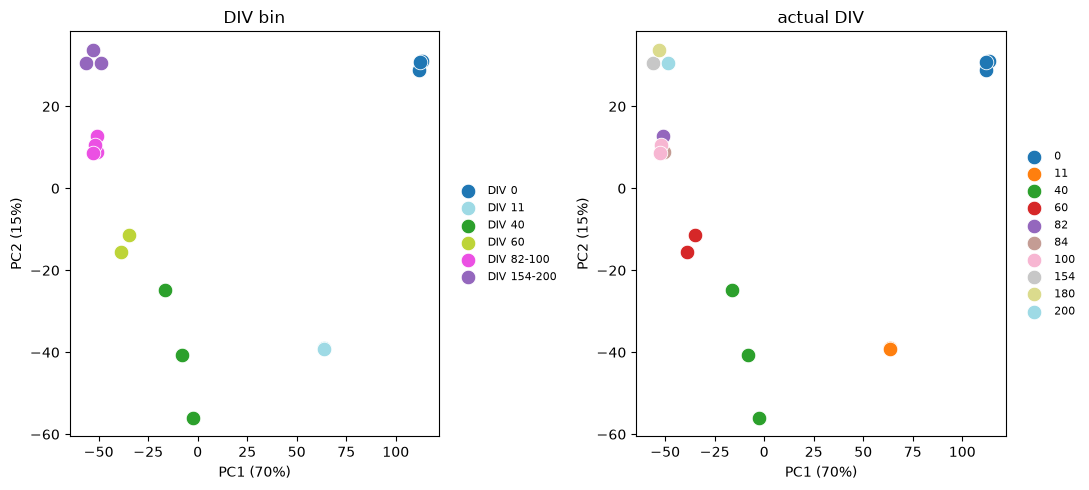

In [41]:
X = VST.to_numpy()
top_var = np.argsort(X.var(axis=0))[-500:]
pca = PCA(n_components=min(10, X.shape[0] - 1)).fit(X[:, top_var])
pcs = pca.transform(X[:, top_var])
var = pca.explained_variance_ratio_ * 100

obs = dds.obs.copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
panels = [("div", "DIV bin"), ("div_actual", "actual DIV")]
for ax, (col, title) in zip(axes, panels):
    vals = obs[col]
    if col == "div":
        groups, cmap = BIN_ORDER, BIN_COLORS
    else:
        groups = sorted(vals.unique())
        pal = mpl.colormaps["tab20"].resampled(max(len(groups), 2))
        cmap = {g: pal(i) for i, g in enumerate(groups)}
    for g in groups:
        m = (vals == g).to_numpy()
        lab = DISPLAY.get(g, g if isinstance(g, str) else f"{g:g}")
        ax.scatter(pcs[m, 0], pcs[m, 1], s=110, color=cmap[g], edgecolor="white",
                   linewidth=0.6, label=lab)
    ax.set_xlabel(f"PC1 ({var[0]:.0f}%)"); ax.set_ylabel(f"PC2 ({var[1]:.0f}%)")
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
#plt.savefig(f"{FIG_DIR}/pca_top500.pdf", bbox_inches="tight")
#plt.savefig(f"{FIG_DIR}/pca_top500.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Differential Expression Heatmaps

All heatmaps show the row z-score of the per-bin mean VST. They only choose which rows to plot;
statistics always come from `RES` (DIV 154-200 vs DIV 0). A stats table is saved next to each figure.

In [42]:
def bin_matrix(genes, zscore=True):
    # genes x bins matrix of mean VST, optionally row z-scored
    genes = list(dict.fromkeys(genes))
    M = np.vstack([VST.loc[SAMPLE_BIN == b, genes].mean(axis=0).to_numpy() for b in BIN_ORDER]).T
    if zscore:
        M = (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-9)
    return M, np.array(genes)


def save_stats(genes, name, extra=None):
    t = RES.loc[list(dict.fromkeys(genes)),
                ["baseMean", "log2FoldChange", "log2FoldChange_MLE", "stat", "padj",
                 "direction", "test_status"]].copy()
    if extra is not None:
        t.insert(0, extra[0], [extra[1][g] for g in t.index])
    t.to_csv(f"{SUPP_DIR}/heatmap_{name}_stats.csv")
    return t


def gene_heatmap(genes, name, title=None, cluster=True, vlim=None):
    M, g = bin_matrix(genes)
    n = len(g)
    Z = linkage(M, method="ward") if (cluster and n > 2) else None
    order = dendrogram(Z, no_plot=True)["leaves"][::-1] if Z is not None else list(range(n))
    M, g = M[order], g[order]
    lim = vlim if vlim is not None else max(np.nanpercentile(np.abs(M), 99), 1e-6)

    fig = plt.figure(figsize=(6.5, max(3.5, 0.25 * n + 1.5)))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.18, 1.0], wspace=0.05)
    axd = fig.add_subplot(gs[0, 0]); axd.axis("off")
    if Z is not None:
        dendrogram(Z, ax=axd, orientation="left", no_labels=True,
                   color_threshold=0, above_threshold_color="black")
    axh = fig.add_subplot(gs[0, 1])
    im = axh.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim, interpolation="nearest")
    axh.set_xticks(range(len(BIN_ORDER)))
    axh.set_xticklabels([DISPLAY[b] for b in BIN_ORDER], rotation=90)
    axh.set_yticks(range(n)); axh.set_yticklabels(g, fontsize=8)
    axh.yaxis.tick_right()
    if title:
        axh.set_title(title, fontsize=11)
    cb = fig.colorbar(im, ax=axh, shrink=0.7, pad=0.2, label="row z-score (VST)")
    cb.set_ticks(np.linspace(-lim, lim, 5))
    plt.savefig(f"{FIG_DIR}/heatmap_{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{FIG_DIR}/heatmap_{name}.pdf", bbox_inches="tight")
    plt.show()
    return save_stats(g, name)

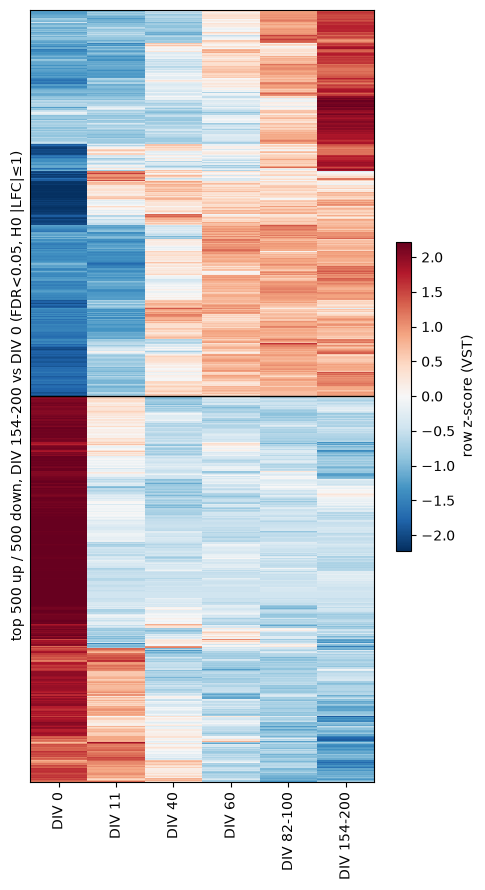

In [47]:
# Top 500 upregulated and downregulated genes heatmap
def clustered_block(genes):
    if len(genes) == 0:
        return np.empty((0, len(BIN_ORDER))), np.array([])
    M, g = bin_matrix(genes)
    if len(g) > 2:
        o = dendrogram(linkage(M, method="ward"), no_plot=True)["leaves"]
        M, g = M[o], g[o]
    return M, g

Mu, gu = clustered_block(TOP_UP.index.tolist())
Md, gd = clustered_block(TOP_DOWN.index.tolist())
mat = np.vstack([Mu, Md])
lim = np.nanpercentile(np.abs(mat), 99)
fig, ax = plt.subplots(figsize=(5, 9))
im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim, interpolation="nearest")
ax.axhline(len(gu) - 0.5, color="k", lw=1)
ax.set_xticks(range(len(BIN_ORDER))); ax.set_xticklabels([DISPLAY[b] for b in BIN_ORDER], rotation=90)
ax.set_yticks([])
ax.set_ylabel(f"top {len(gu)} up / {len(gd)} down, {DISPLAY[LAST]} vs {DISPLAY[REF]} "
              f"(FDR<{PADJ_CUT}, H0 |LFC|≤{LFC_NULL:g})")
fig.colorbar(im, ax=ax, shrink=0.4, label="row z-score (VST)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/heatmap_genomewide_top{TOP_N}.png", dpi=300)
plt.savefig(f"{FIG_DIR}/heatmap_genomewide_top{TOP_N}.pdf")
plt.show()

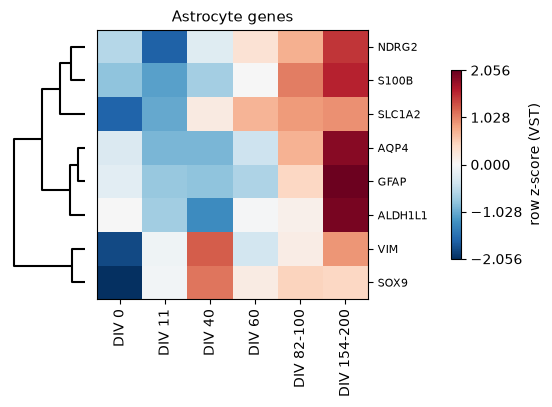

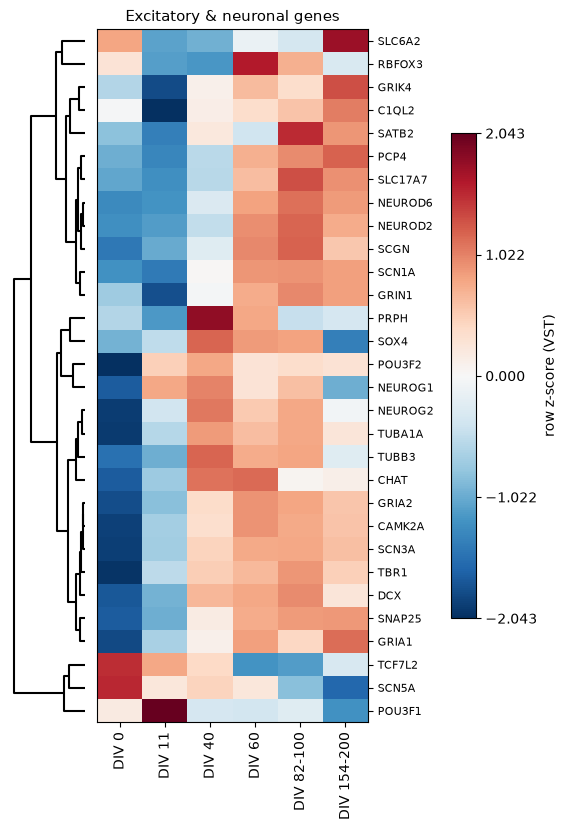

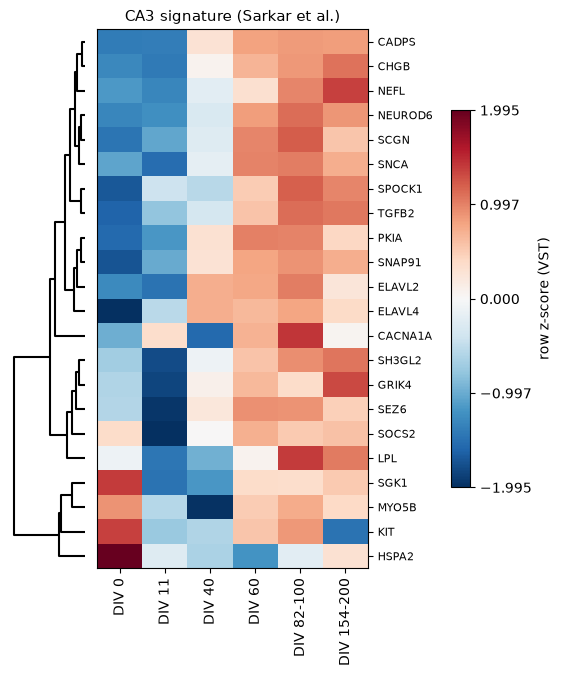

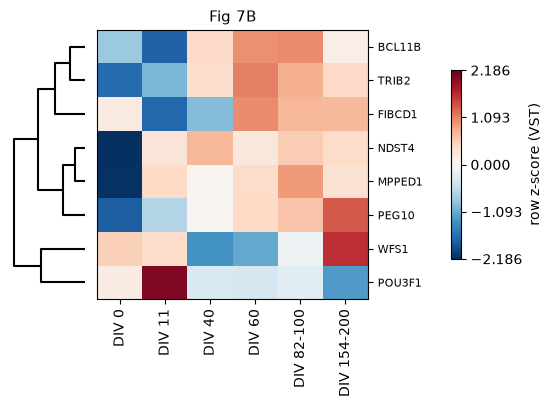

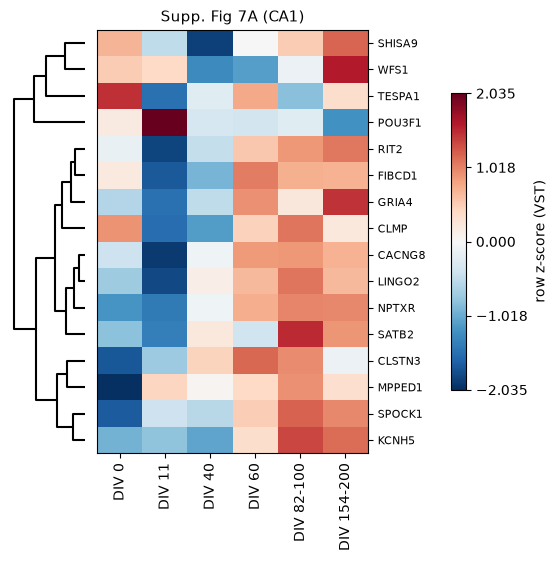

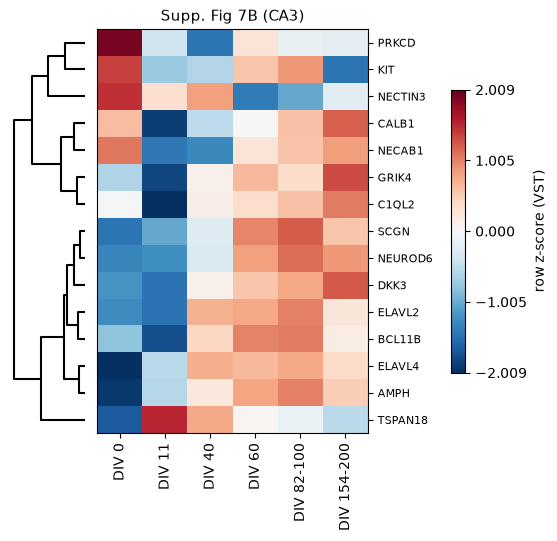

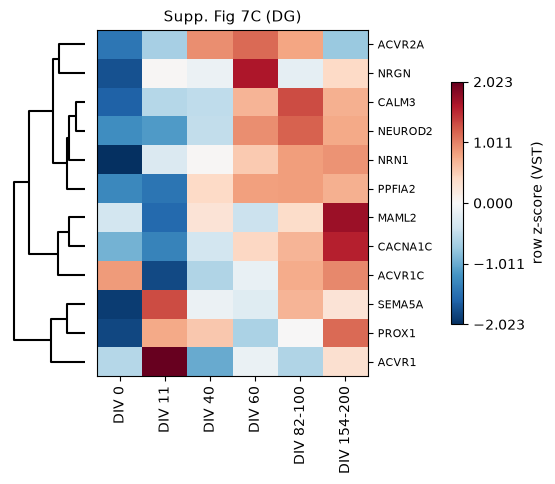

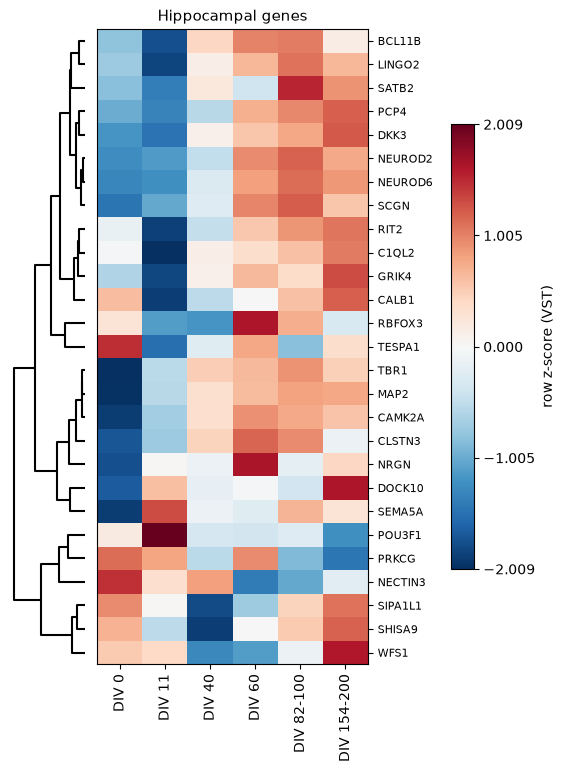

In [49]:
# Marker panels for plots
HEATMAPS = [
    ("astrocyte",                 "Astrocyte genes",              None),
    ("excitatory_neuronal",       "Excitatory & neuronal genes",  None),
    ("ca3_sarkar",                "CA3 signature (Sarkar et al.)", None),
    ("fig7b",                     "Fig 7B",                       None),
    ("supp7a_CA1",                "Supp. Fig 7A (CA1)",           None),
    ("supp7b_CA3",                "Supp. Fig 7B (CA3)",           None),
    ("supp7c_DG",                 "Supp. Fig 7C (DG)",            None),
    ("hippocampal_mixed",         "Hippocampal genes",            None),
]
HEATMAP_STATS = {}
for key, title, vlim in HEATMAPS:
    HEATMAP_STATS[key] = gene_heatmap(GENE_LISTS[key], key, title, vlim=vlim)

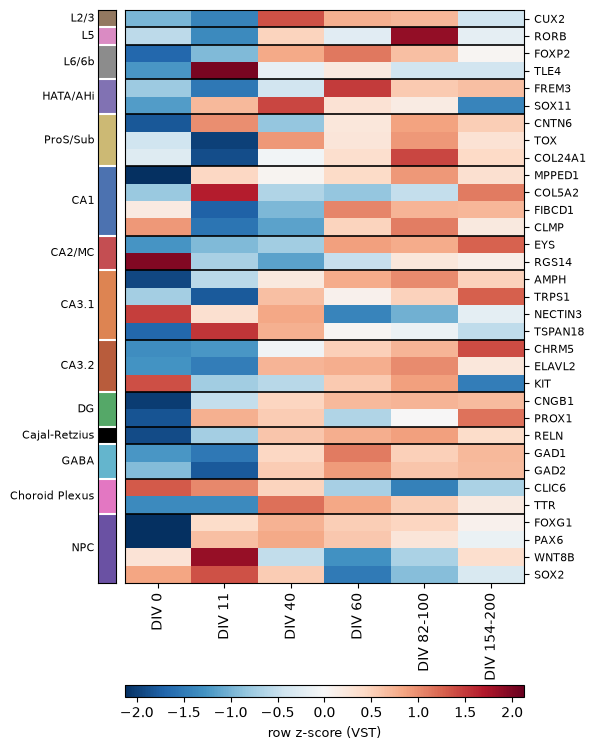

,region,baseMean,log2FoldChange,log2FoldChange_MLE,stat,padj,direction,test_status
gene,,,,,,,,
CUX2,L2/3,2012.544810,0.466621,0.515904,0.000000,1.000000e+00,ns,tested
RORB,L5,1338.599761,0.175247,0.195000,0.000000,1.000000e+00,ns,tested
FOXP2,L6/6b,2255.992694,6.052866,6.147465,9.801136,2.981119e-21,up,tested
TLE4,L6/6b,6073.804828,0.662597,0.718150,0.000000,1.000000e+00,ns,tested
FREM3,HATA/AHi,23.130739,2.504352,3.125306,2.066185,1.065400e-01,ns,tested
SOX11,HATA/AHi,21591.230929,-0.156387,-0.170079,0.000000,1.000000e+00,ns,tested
CNTN6,ProS/Sub,265.170694,7.547960,7.951827,5.943402,2.460058e-08,up,tested
TOX,ProS/Sub,3940.765295,1.291255,1.372155,1.081933,5.702844e-01,ns,tested
COL24A1,ProS/Sub,453.640988,0.842881,1.283109,0.330980,1.000000e+00,ns,tested


In [19]:
# Hippocampal representative genes by region
gene2region = {}
for region, gl in REGION_PANELS:
    for g in gl:
        gene2region.setdefault(g, region)
padj_sort = RES["padj"].fillna(1.0)
ordered = [g for region, _ in REGION_PANELS
           for g in sorted([x for x in gene2region if gene2region[x] == region],
                           key=lambda x: padj_sort[x])]
M, genes_r = bin_matrix(ordered)
regions = [r for r, _ in REGION_PANELS]
codes = np.array([regions.index(gene2region[g]) for g in genes_r])
sizes = [int((codes == i).sum()) for i in range(len(regions))]
bounds = np.cumsum(sizes)[:-1]
lim = np.nanpercentile(np.abs(M), 99)
n = len(genes_r)

fig = plt.figure(figsize=(5.5, max(6, 0.24 * n + 1)))
gs = fig.add_gridspec(2, 2, width_ratios=[0.045, 1.0], height_ratios=[1.0, 0.02],
                      wspace=0.04, hspace=0.35)
axs = fig.add_subplot(gs[0, 0])
axs.imshow(codes.reshape(-1, 1), aspect="auto",
           cmap=ListedColormap([REGION_COLORS[r] for r in regions]),
           vmin=0, vmax=len(regions) - 1, interpolation="nearest")
axs.set_xticks([]); axs.set_yticks([])
starts = np.concatenate(([0], bounds)); ends = np.concatenate((bounds, [n]))
for r, s0, e0 in zip(regions, starts, ends):
    if e0 > s0:
        axs.text(-0.7, (s0 + e0 - 1) / 2, r, ha="right", va="center", fontsize=8, clip_on=False)
axh = fig.add_subplot(gs[0, 1])
im = axh.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim, interpolation="nearest")
axh.set_yticks(range(n)); axh.set_yticklabels(genes_r, fontsize=8); axh.yaxis.tick_right()
axh.set_xticks(range(len(BIN_ORDER))); axh.set_xticklabels([DISPLAY[b] for b in BIN_ORDER], rotation=90)
for b in bounds:
    axs.axhline(b - 0.5, color="white", lw=1.5); axh.axhline(b - 0.5, color="black", lw=1.2)
cb = fig.colorbar(im, cax=fig.add_subplot(gs[1, 1]), orientation="horizontal")
cb.set_label("row z-score (VST)", fontsize=9)
plt.savefig(f"{FIG_DIR}/heatmap_regions_representative.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIG_DIR}/heatmap_regions_representative.pdf", bbox_inches="tight")
plt.show()
save_stats(genes_r, "regions_representative", extra=("region", gene2region))

## 6. Timepoint plots (ΔVST vs DIV 0)

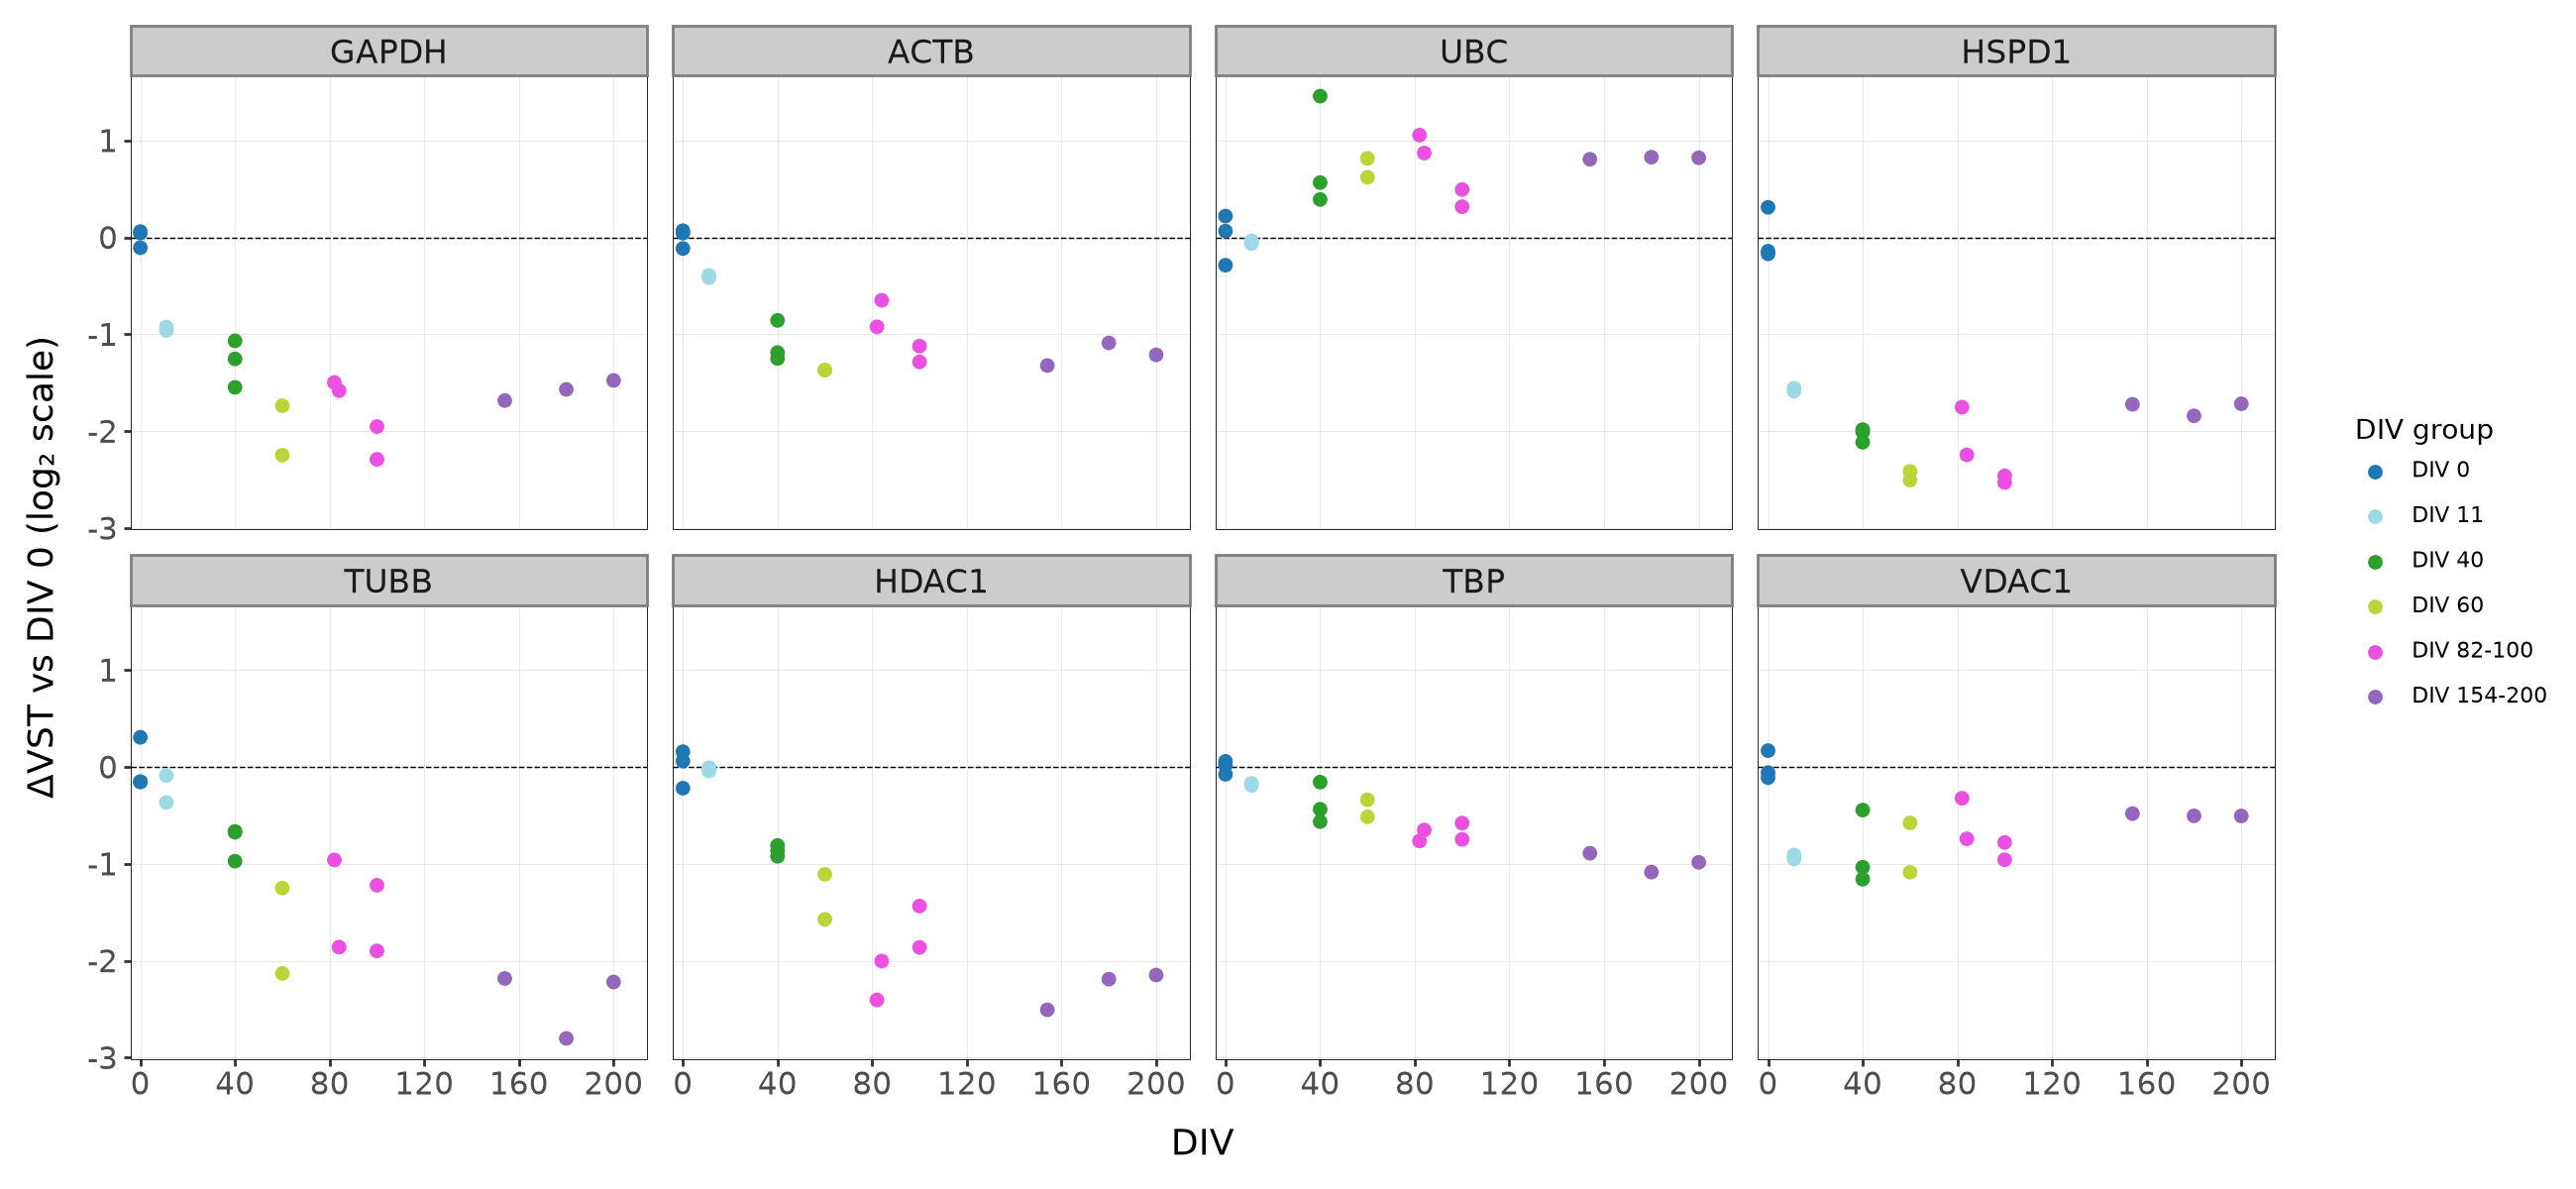

In [50]:
from plotnine import (ggplot, aes, geom_point, geom_hline, facet_wrap, labs, theme_bw, theme,
                      scale_x_continuous, scale_color_manual, element_text, element_line,
                      element_blank, element_rect)

def timepoint_plot(genes, name, ncol=4, width=13, height=4):
    base = VST.loc[SAMPLE_BIN == REF, genes].mean(axis=0)
    long = (VST[genes] - base).reset_index(names="sample").melt(
        id_vars="sample", var_name="gene", value_name="dvst")
    long = long.merge(dds.obs[["div", "div_actual"]], left_on="sample", right_index=True)
    long["div_label"] = pd.Categorical(long["div"].map(DISPLAY),
                                       categories=[DISPLAY[b] for b in BIN_ORDER])
    long["gene"] = pd.Categorical(long["gene"], categories=genes)
    xb = np.arange(0, 210, 40)
    p = (ggplot(long, aes("div_actual", "dvst", color="div_label"))
         + geom_hline(yintercept=0, linetype="dashed", size=0.3)
         + geom_point(size=2)
         + facet_wrap("gene", ncol=ncol)
         + scale_x_continuous(breaks=xb, labels=[str(int(d)) for d in xb],
                              limits=(0, 210), expand=(0.02, 0))
         + scale_color_manual(values={DISPLAY[b]: c for b, c in BIN_COLORS.items()})
         + labs(x="DIV", y=f"ΔVST vs {DISPLAY[REF]} (log₂ scale)", color="DIV group")
         + theme_bw(base_size=10)
         + theme(axis_text=element_text(size=11), axis_title=element_text(size=13),
                 strip_text=element_text(size=12),
                 panel_grid_major=element_line(size=0.2, color="0.85"),
                 panel_grid_minor=element_blank(),
                 panel_border=element_rect(size=0.3, color="black", fill=None),
                 figure_size=(width, height)))
    p.save(f"{FIG_DIR}/timepoint_{name}.pdf", width=width, height=height, verbose=False)
    p.save(f"{FIG_DIR}/timepoint_{name}.png", dpi=300, width=width, height=height, verbose=False)
    return p

timepoint_plot(GENE_LISTS["housekeeping_neuronal"], "housekeeping", width=13, height=6)

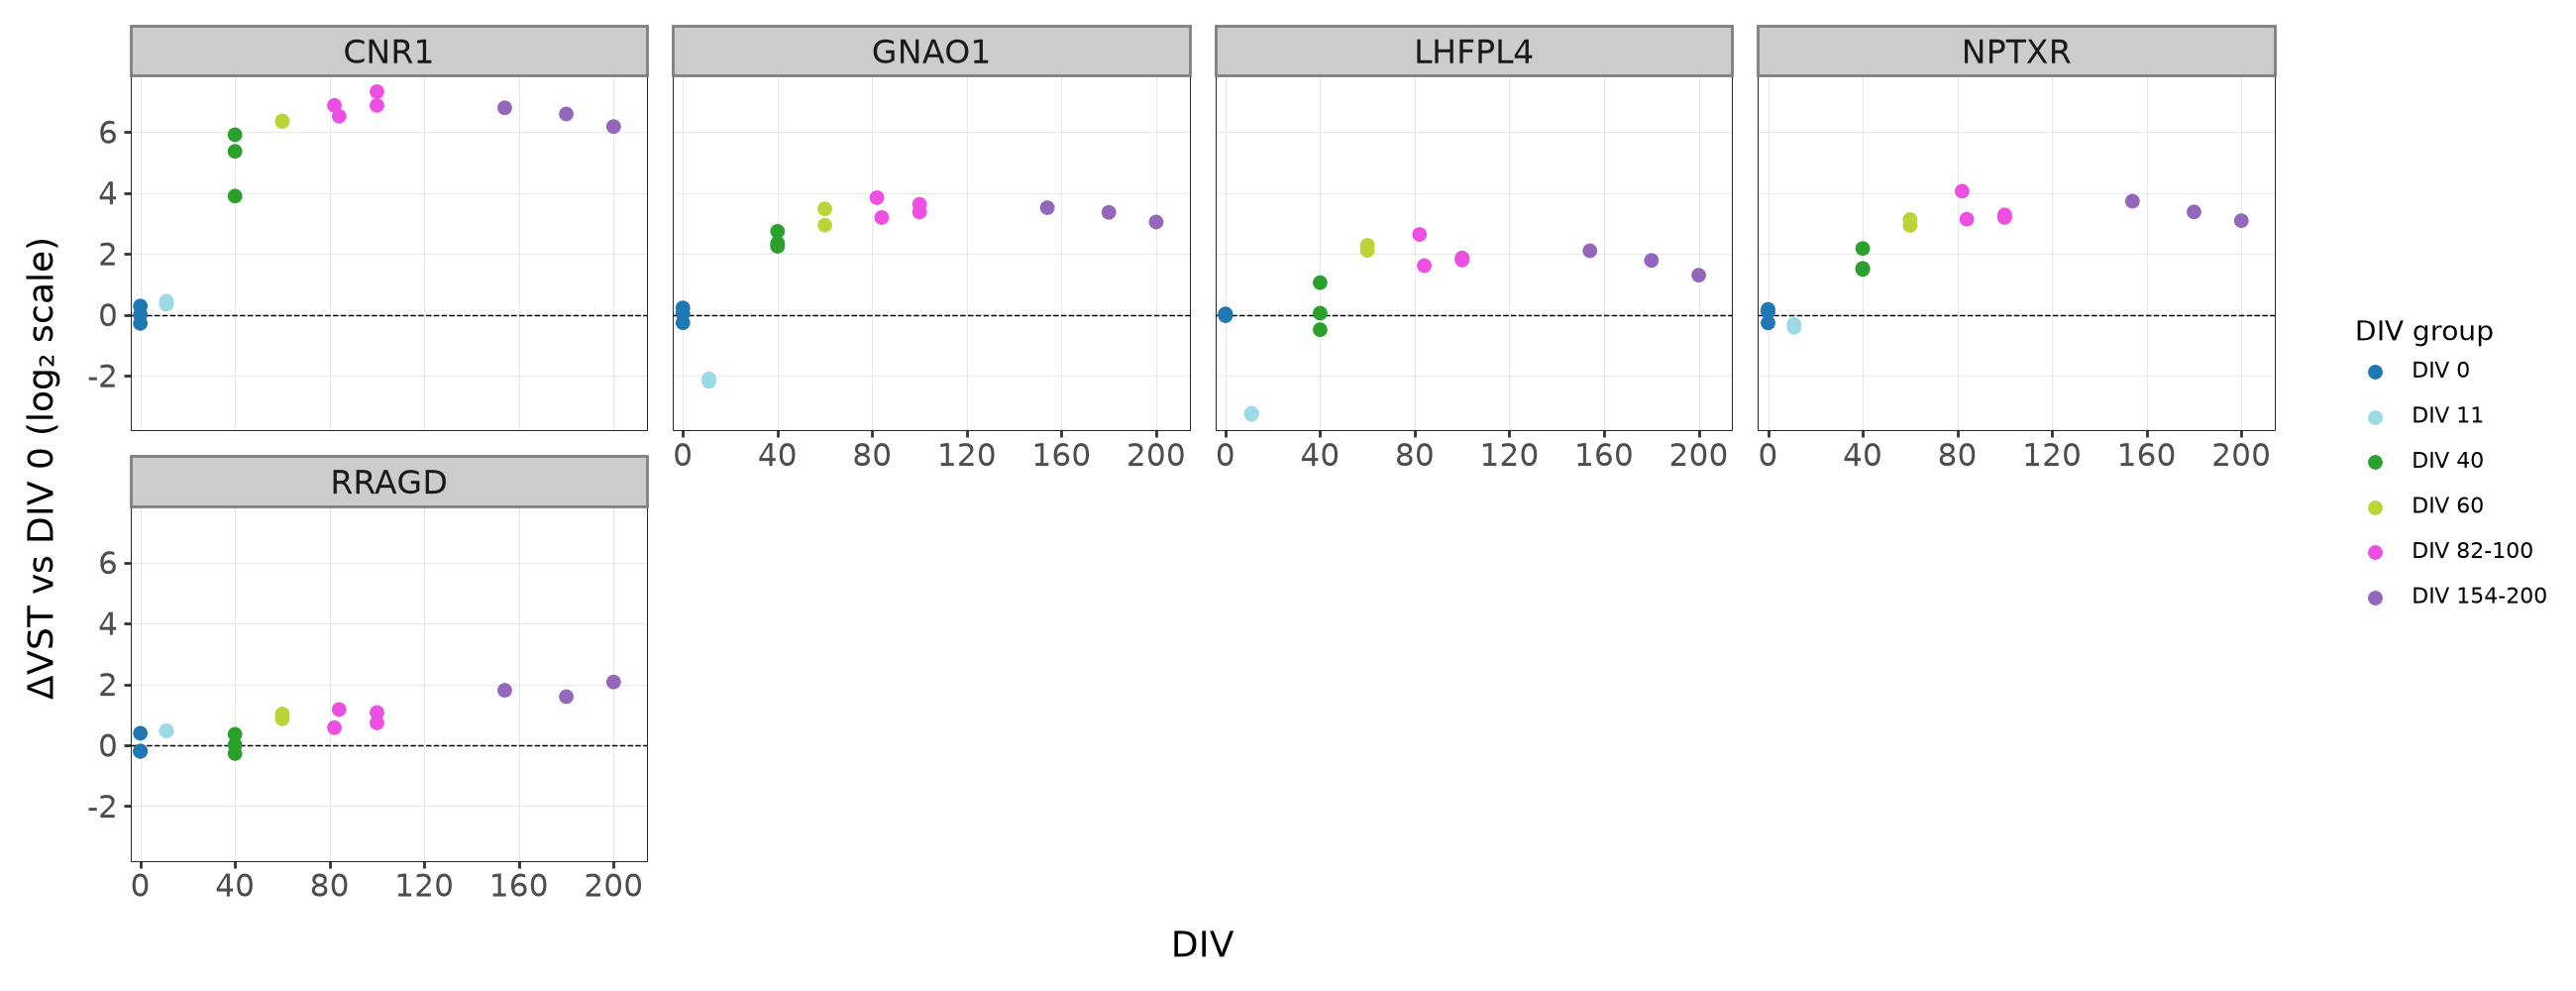

In [51]:
timepoint_plot(GENE_LISTS["tp_maturation"], "maturation", width=13, height=5)

## 7. CA3 signature score (Sarkar et al.)

div
DIV0           0.510
DIV11          0.380
DIV40          0.855
DIV60          1.236
DIV82to100     1.358
DIV154to200    1.253
Name: ssGSEA_NES, dtype: float64


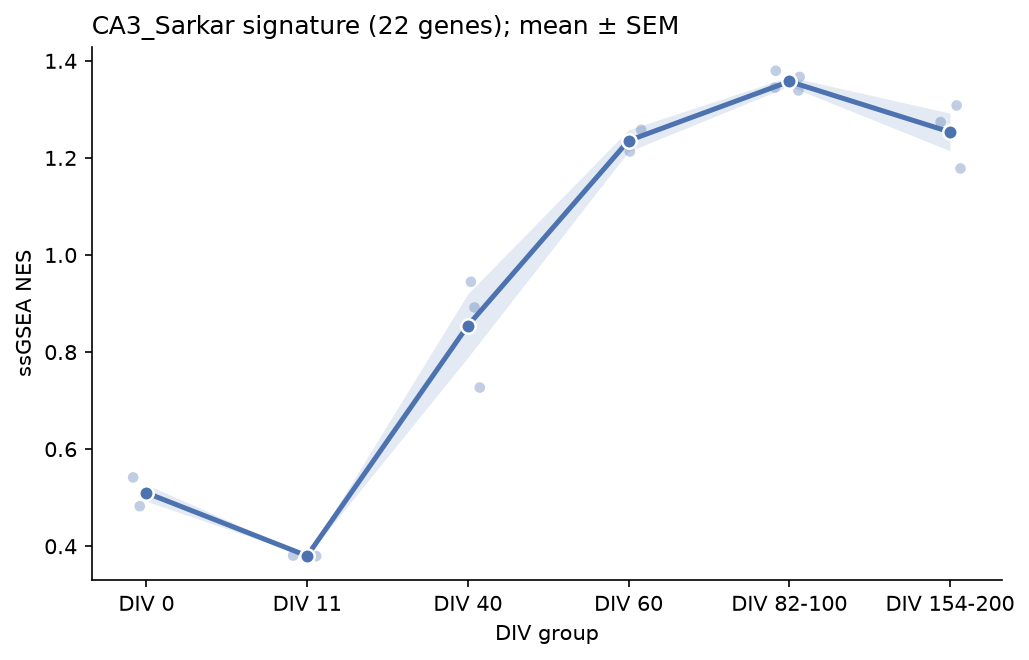

div
DIV0           0.509916
DIV11          0.380183
DIV40          0.854570
DIV60          1.235614
DIV82to100     1.357545
DIV154to200    1.253458
Name: score, dtype: float64

In [54]:
# ssGEA score with gseapy
# Score is normalized within and across samples

SIG_NAME, SIG_GENES = "CA3_Sarkar", GENE_LISTS["ca3_sarkar"]

def ssgsea_score(genes, value="NES", weight=0.25):
    r = gp.ssgsea(data=VST.T, gene_sets={SIG_NAME: list(dict.fromkeys(genes))},
                  sample_norm_method="rank", weight=weight, min_size=5, max_size=5000,
                  permutation_num=0, outdir=None, no_plot=True, threads=N_CPUS, verbose=False)
    t = r.res2d.pivot(index="Name", columns="Term", values=value).astype(float)
    return t[SIG_NAME].reindex(VST.index)

def plot_score(score, ylabel, name, color="#4C72B0"):
    df = pd.DataFrame({"score": score, "div": SAMPLE_BIN}, index=VST.index)
    g = df.groupby("div")["score"]
    mean, sem = g.mean().reindex(BIN_ORDER), g.sem().fillna(0).reindex(BIN_ORDER)
    xs = np.arange(len(BIN_ORDER))
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    ax.fill_between(xs, mean - sem, mean + sem, color=color, alpha=0.15, lw=0)
    rng = np.random.default_rng(0)
    xpos = df["div"].map({b: i for i, b in enumerate(BIN_ORDER)}).to_numpy(float)
    ax.scatter(xpos + rng.uniform(-0.09, 0.09, len(df)), df["score"], s=26, color=color,
               alpha=0.35, edgecolors="none")
    ax.plot(xs, mean, color=color, lw=2.4)
    ax.scatter(xs, mean, s=48, color=color, edgecolors="white", linewidths=1.2, zorder=4)
    ax.set_xticks(xs); ax.set_xticklabels([DISPLAY[b] for b in BIN_ORDER])
    ax.set_xlabel("DIV group"); ax.set_ylabel(ylabel)
    ax.set_title(f"{SIG_NAME} signature ({N_SIG_GENES} genes); mean ± SEM",
                 loc="left", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/signature_{SIG_NAME}_{name}.pdf", bbox_inches="tight")
    plt.show()
    return mean

N_SIG_GENES = len(set(SIG_GENES) & set(VST.columns))

SIG_SCORES = dds.obs[["div", "div_actual"]].join(
    ssgsea_score(SIG_GENES).rename("ssGSEA_NES"))
SIG_SCORES.to_csv(f"{SUPP_DIR}/signature_{SIG_NAME}_scores.csv")
print(SIG_SCORES.groupby("div")["ssGSEA_NES"].mean().reindex(BIN_ORDER).round(3))
plot_score(SIG_SCORES["ssGSEA_NES"], "ssGSEA NES", "ssgsea")

## 8. Volcano plots (every bin vs DIV 0)

x = shrunk log₂FC (positive = higher in the later culture stage bin),
y = −log₁₀ padj from the thresholded test.

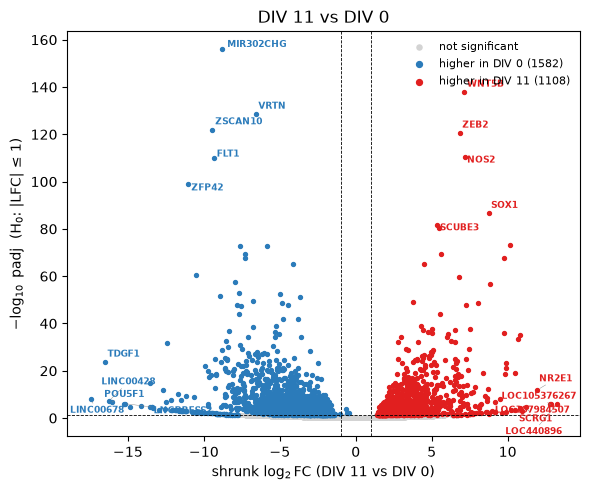

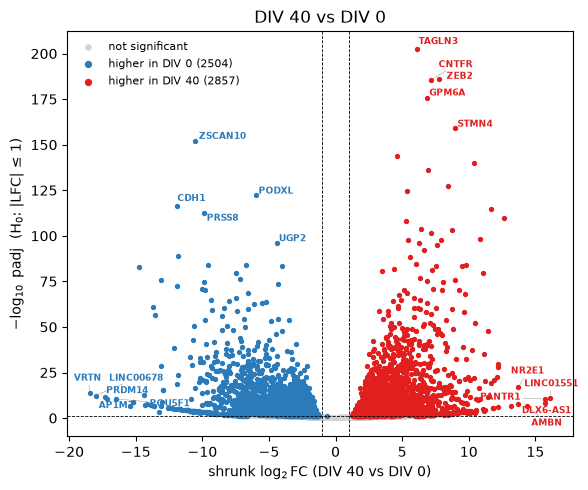

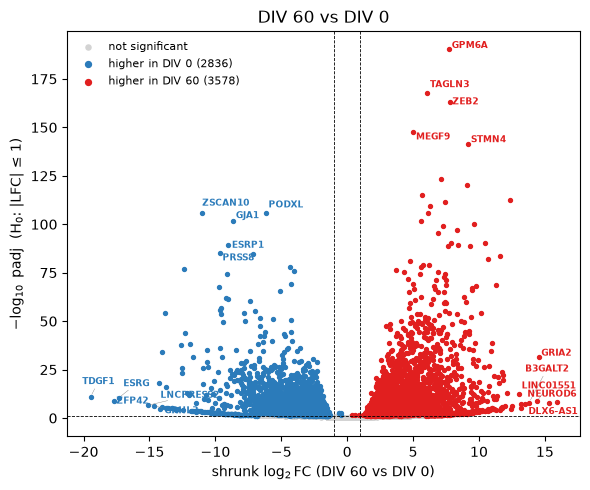

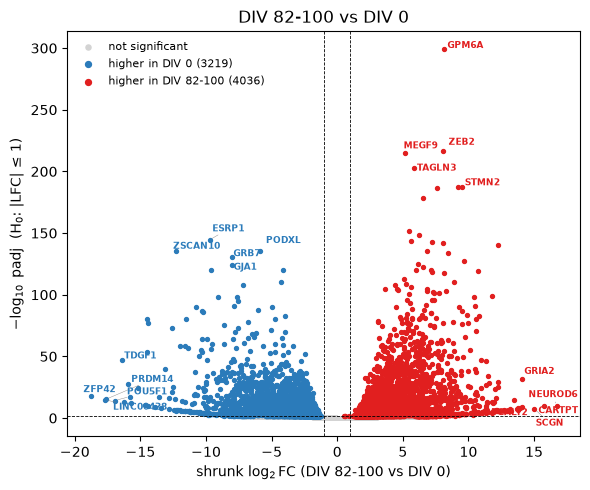

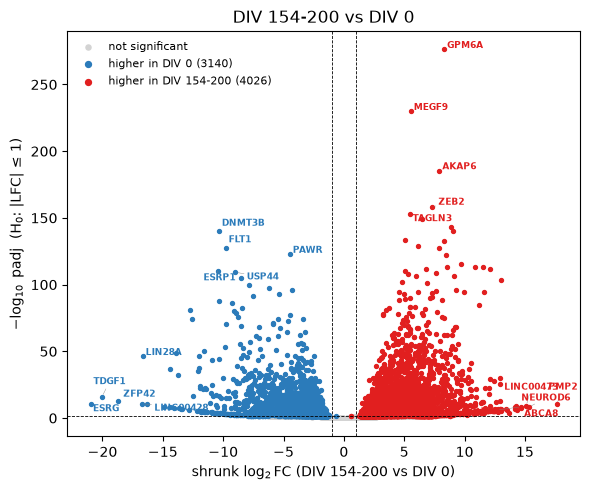

In [65]:
# To plot volcano plots for DIV0 vs DIV11, DIV0 vs DIV 40, DIV0 vs DIV60, DIV0 vs DIV 82-100, DIV 0 vs DIV 154-200

try:
    from adjustText import adjust_text
    HAVE_ADJUSTTEXT = True
except ImportError:
    HAVE_ADJUSTTEXT = False

def volcano(res, test, ref, n_label=5, markers=VOLCANO_MARKERS):
    r = res.dropna(subset=["log2FoldChange", "padj"]).copy()
    r["y"] = -np.log10(r["padj"].clip(lower=1e-300))
    up, down = r["direction"] == "up", r["direction"] == "down"
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(r.loc[~(up | down), "log2FoldChange"], r.loc[~(up | down), "y"], s=6,
               c="lightgrey", rasterized=True, label="not significant")
    ax.scatter(r.loc[down, "log2FoldChange"], r.loc[down, "y"], s=8, c="#2b7bba",
               rasterized=True, label=f"higher in {DISPLAY[ref]} ({down.sum()})")
    ax.scatter(r.loc[up, "log2FoldChange"], r.loc[up, "y"], s=8, c="#e11f1f",
               rasterized=True, label=f"higher in {DISPLAY[test]} ({up.sum()})")

    lab = pd.concat([
        r[up].nlargest(n_label, "log2FoldChange"), r[down].nsmallest(n_label, "log2FoldChange"),
        r[up].sort_values(["padj", "log2FoldChange"], ascending=[True, False]).head(n_label),
        r[down].sort_values(["padj", "log2FoldChange"], ascending=[True, True]).head(n_label)])
    lab = lab[~lab.index.duplicated()]
    mk = [g for g in markers if g in r.index]
    texts = [ax.text(r.at[g, "log2FoldChange"], r.at[g, "y"], g, fontsize=6.5, fontweight="bold",
                     color="black" if g in mk else ("#e11f1f" if r.at[g, "log2FoldChange"] > 0 else "#2b7bba"))
             for g in list(lab.index) + [m for m in mk if m not in lab.index]]
    if HAVE_ADJUSTTEXT and texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.3))

    ax.axhline(-np.log10(PADJ_CUT), ls="--", lw=0.6, c="k")
    for v in (LFC_NULL, -LFC_NULL):
        ax.axvline(v, ls="--", lw=0.6, c="k")
    ax.set_xlabel(rf"shrunk $\log_2$FC ({DISPLAY[test]} vs {DISPLAY[ref]})")
    ax.set_ylabel(rf"$-\log_{{10}}$ padj  (H$_0$: |LFC| ≤ {LFC_NULL:g})")
    ax.set_title(f"{DISPLAY[test]} vs {DISPLAY[ref]}")
    ax.legend(frameon=False, fontsize=8, markerscale=1.5)
    untested = [g for g in mk if pd.isna(res.at[g, "padj"])]
    if untested:
        ax.text(0.01, -0.13, "not tested: " + ", ".join(untested), transform=ax.transAxes,
                fontsize=7, color="dimgray")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/volcano_{test}_vs_{ref}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

for b, res_b in RESULTS.items():
    volcano(res_b, b, REF)

## 9. GO enrichment

Gene lists are exactly the significant genes of each comparison (`direction` = up / down).
The threshold |LFC| > 1 is already inside the test, so no second cutoff is applied to the
shrunk LFC. Background = genes with an adjusted p-value in that comparison. The same (newest)
Enrichr library version is used for every comparison.

In [57]:
# Enrichr GO libraries pinned to a fixed version for reproducibility
GO_YEAR = "2026"   # Enrichr library version that was used in the paper

def pinned_library(prefix, available, year=GO_YEAR):
    name = f"{prefix}_{year}"
    if name not in available:
        versions = sorted(n for n in available if n.startswith(prefix + "_20"))
        raise ValueError(f"{name} not found in Enrichr; available versions: {versions}")
    return name

def run_go(genes, background, libraries):
    cols = ["Gene_set", "Term", "P-value", "Adjusted P-value", "Odds Ratio",
            "Combined Score", "Genes"]
    if len(genes) < 5:
        return pd.DataFrame(columns=cols)
    enr = gp.enrichr(gene_list=list(genes), gene_sets=libraries, background=list(background),
                     organism=GO_ORGANISM, outdir=None)
    return enr.results.sort_values("Adjusted P-value").reset_index(drop=True)

GO = {}
if RUN_GO:
    available = gp.get_library_name(organism=GO_ORGANISM)
    GO_LIBS = [pinned_library(p, available) for p in
               ("GO_Biological_Process", "GO_Molecular_Function", "GO_Cellular_Component")]
    GO_BP = GO_LIBS[0]
    print("libraries:", GO_LIBS)
    for b, r in RESULTS.items():
        bg = r.index[r["padj"].notna()]
        up_g = r.index[r["direction"] == "up"]; dn_g = r.index[r["direction"] == "down"]
        GO[b] = {"up": run_go(up_g, bg, GO_LIBS).assign(direction="up", comparison=r["comparison"].iat[0]),
                 "down": run_go(dn_g, bg, GO_LIBS).assign(direction="down", comparison=r["comparison"].iat[0]),
                 "n_up": len(up_g), "n_down": len(dn_g), "n_background": len(bg)}
        n_sig = [(GO[b][d]["Adjusted P-value"] < 0.05).sum() for d in ("up", "down")]
        print(f"{DISPLAY[b]:>12}: {len(up_g)} up / {len(dn_g)} down genes, "
              f"background {len(bg)} -> {n_sig[0]} / {n_sig[1]} GO terms padj<0.05")
    GO_UP, GO_DOWN = GO[LAST]["up"], GO[LAST]["down"]
    cols = ["Gene_set", "Term", "Adjusted P-value", "Odds Ratio", "Combined Score"]
    print("\nTop terms, higher at", DISPLAY[LAST]); print(GO_UP[cols].head(10).to_string(index=False))
    print("\nTop terms, higher at", DISPLAY[REF]);  print(GO_DOWN[cols].head(10).to_string(index=False))
else:
    print("RUN_GO = False; skipping enrichment")

libraries: ['GO_Biological_Process_2026', 'GO_Molecular_Function_2026', 'GO_Cellular_Component_2026']
      DIV 11: 1108 up / 1582 down genes, background 20564 -> 60 / 136 GO terms padj<0.05
      DIV 40: 2857 up / 2504 down genes, background 21583 -> 165 / 334 GO terms padj<0.05
      DIV 60: 3578 up / 2836 down genes, background 21074 -> 213 / 519 GO terms padj<0.05
  DIV 82-100: 4036 up / 3219 down genes, background 23111 -> 298 / 603 GO terms padj<0.05
 DIV 154-200: 4026 up / 3140 down genes, background 22092 -> 289 / 470 GO terms padj<0.05

Top terms, higher at DIV 154-200
                  Gene_set                                              Term  Adjusted P-value  Odds Ratio  Combined Score
GO_Cellular_Component_2026                    Neuron Projection (GO:0043005)      2.628390e-31    3.168916      241.925713
GO_Biological_Process_2026       Chemical Synaptic Transmission (GO:0007268)      1.269912e-30    4.902119      378.985729
GO_Biological_Process_2026           Nervous S

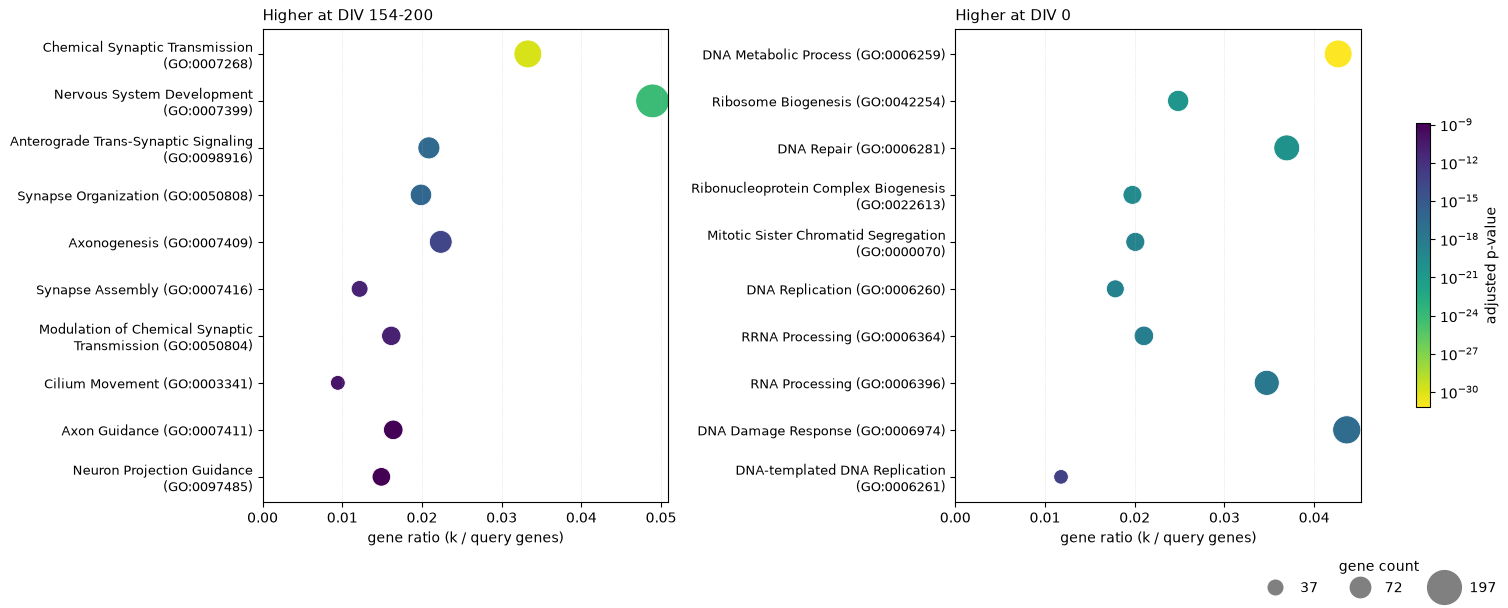

In [58]:
def _k(df):
    return df["Genes"].astype(str).str.split(";").apply(len)

def go_dotplot(tables, n_query, titles, fname, gene_set=None, top=10, wrap=38,
               figsize=(15, 6), bubble=3):
    # Tables: list of enrichment tables (one panel each). gene ratio = k / n query genes.
    preps = []
    for df, nq in zip(tables, n_query):
        d = df.copy()
        if gene_set is not None:
            d = d[d["Gene_set"] == gene_set]
        d = d.dropna(subset=["Adjusted P-value"]).sort_values("Adjusted P-value").head(top)
        d["k"] = _k(d); d["ratio"] = d["k"] / nq
        preps.append(d.iloc[::-1])
    allp = pd.concat([d["Adjusted P-value"] for d in preps])
    norm = LogNorm(vmin=max(allp.min(), 1e-300), vmax=max(allp.max(), allp.min() * 10))
    fig, axes = plt.subplots(1, len(preps), figsize=figsize, layout="constrained", squeeze=False)
    sc = None
    for ax, d, t in zip(axes[0], preps, titles):
        y = np.arange(len(d))
        sc = ax.scatter(d["ratio"], y, s=d["k"] * bubble, c=d["Adjusted P-value"],
                        cmap="viridis_r", norm=norm, edgecolor="white", linewidth=0.6)
        ax.set_yticks(y)
        ax.set_yticklabels(["\n".join(textwrap.wrap(x, wrap)[:2]) for x in d["Term"]], fontsize=9)
        ax.set_xlim(left=0); ax.margins(x=0.2, y=0.06)
        ax.set_xlabel("gene ratio (k / query genes)"); ax.set_title(t, loc="left", fontsize=10.5)
        ax.grid(axis="x", ls=":", lw=0.5, alpha=0.5)
    fig.colorbar(sc, ax=axes[0].tolist(), shrink=0.6, label="adjusted p-value")
    allk = pd.concat([d["k"] for d in preps])
    if len(allk):
        ks = sorted({int(allk.min()), int(allk.median()), int(allk.max())})
        fig.legend([Line2D([], [], marker="o", ls="", color="grey", markersize=(k * bubble) ** 0.5)
                    for k in ks], [str(k) for k in ks], title="gene count",
                   loc="outside lower right", frameon=False, ncol=len(ks))
    fig.savefig(f"{FIG_DIR}/{fname}.pdf", bbox_inches="tight")
    fig.savefig(f"{FIG_DIR}/{fname}.png", dpi=200, bbox_inches="tight")
    plt.show()

if RUN_GO:
    go_dotplot([GO_UP, GO_DOWN], [GO[LAST]["n_up"], GO[LAST]["n_down"]],
               [f"Higher at {DISPLAY[LAST]}", f"Higher at {DISPLAY[REF]}"],
               "GO_BP_top10_main", gene_set=GO_BP)

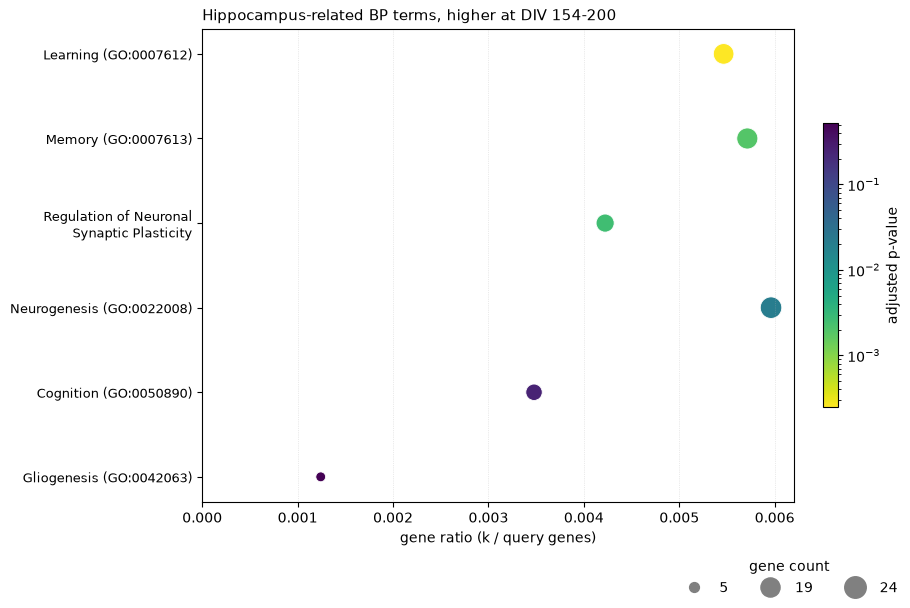

In [64]:
# To search for hippocampus-related GO terms
# adjusted p-values are from the full test, not re-adjusted for the subset.
HIPPO_KEYWORDS = ["hippocamp", "learning", "memory", "cognition", "spatial", "plasticity",
                  "astrocyte", "information", "gliogenesis", "dentate gyrus", "neurogenesis"]
# Keep only the most significant term containing to refrain from plotting GO terms
# that are too similar to each other
REDUNDANT_GROUPS = ["learning", "memory", "differentiation", "neurogenesis", "recognition",
                    "plasticity"]   
if RUN_GO:
    pat = re.compile("|".join(HIPPO_KEYWORDS), flags=re.I)
    d = GO_UP[(GO_UP["Gene_set"] == GO_BP) & GO_UP["Term"].str.contains(pat)].copy()
    d = d.sort_values("Adjusted P-value")
    drop = []
    for phrase in REDUNDANT_GROUPS:
        m = d[d["Term"].str.contains(phrase, case=False)]
        drop += m.index[1:].tolist()
    d = d.drop(index=set(drop))
    d.to_csv(f"{SUPP_DIR}/GO_hippocampal_subset_{LAST}_vs_{REF}.csv", index=False)
    if len(d):
        go_dotplot([d], [GO[LAST]["n_up"]], [f"Hippocampus-related BP terms, higher at {DISPLAY[LAST]}"],
                   "GO_BP_hippocampal_subset", top=6, figsize=(9, 6), bubble=10, wrap=30)
    else:
        print("no keyword-matching terms")

## 11. Versions

In [63]:
import importlib.metadata as im
for p in ["pydeseq2", "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
          "plotnine", "gseapy", "adjustText", "xlsxwriter"]:
    try:
        print(f"{p:14s}{im.version(p)}")
    except im.PackageNotFoundError:
        print(f"{p:14s}not installed")

pydeseq2      0.5.4
numpy         2.5.0
pandas        2.3.3
scipy         1.18.0
scikit-learn  1.9.0
matplotlib    3.11.0
plotnine      0.15.8
gseapy        1.3.1
adjustText    1.4.0
xlsxwriter    3.2.9
